In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.robust.norms as norms
import os
import pandas as pd
import numpy as np
from scipy.optimize import least_squares

Чтение данных

In [3]:
# Путь к директории с CSV-файлами
DATA_DIR = r"C:\proga\ippi\generators\nonlineral\data_outliers"

def parse_filename(filename):
    """
    Извлекает метаинформацию из имени файла.
    
    Структура имени:
      <signal_type>_<params>_<error_category>_<n1>[_<n2>_...].csv
      signal_type:
        l – линия, параметры: a, b (y = a*x + b)
        e – эллипс, параметры: cx, cy, a_axis, b_axis, theta
        p – парабола, параметры: h, k, A 
        h – гипербола, параметры: h, k, a, b
      error_category:
        l – выброс в форме линии
        s – статические выбросы
        r – случайное распределение помех
      После error_category идут от 1 до 5 чисел, каждое задаёт количество точек выброса для группы.
    """

    # Убираем расширение .csv
    name = filename.replace(".csv", "")
    parts = name.split("_")
    
    if not parts:
        raise ValueError("Неверное имя файла: пустая строка.")
    
    # Первый символ — тип сигнала
    signal_type = parts[0]
    meta = {"signal_type": signal_type}
    idx = 1
    
    if signal_type == "l":
        # Ожидается два параметра: a и b
        if len(parts) < idx + 2 + 1:
            raise ValueError(f"Неверное имя файла {filename}: недостаточно параметров для линии.")
        try:
            a = float(parts[idx])
            b = float(parts[idx + 1])
        except ValueError:
            raise ValueError(f"Неверный формат параметров для линии в {filename}.")
        meta["params"] = {"a": a, "b": b}
        idx += 2
    elif signal_type == "e":
        # Эллипс: 5 параметров: cx, cy, a_axis, b_axis, theta
        if len(parts) < idx + 5 + 1:
            raise ValueError(f"Неверное имя файла {filename}: недостаточно параметров для эллипса.")
        try:
            cx, cy, a_axis, b_axis, theta = map(float, parts[idx:idx+5])
        except ValueError:
            raise ValueError(f"Неверный формат параметров для эллипса в {filename}.")
        meta["params"] = {"cx": cx, "cy": cy, "a_axis": a_axis, "b_axis": b_axis, "theta": theta}
        idx += 5
    elif signal_type == "p":
        # Парабола: 3 параметра: h, k, A
        if len(parts) < idx + 3 + 1:
            raise ValueError(f"Неверное имя файла {filename}: недостаточно параметров для параболы.")
        try:
            h, k, A = map(float, parts[idx:idx+3])
        except ValueError:
            raise ValueError(f"Неверный формат параметров для параболы в {filename}.")
        meta["params"] = {"h": h, "k": k, "A": A}
        idx += 3
    elif signal_type == "h":
        # Гипербола: 4 параметра: h, k, a, b
        if len(parts) < idx + 4 + 1:
            raise ValueError(f"Неверное имя файла {filename}: недостаточно параметров для гиперболы.")
        try:
            h_val, k_val, a_val, b_val = map(float, parts[idx:idx+4])
        except ValueError:
            raise ValueError(f"Неверный формат параметров для гиперболы в {filename}.")
        meta["params"] = {"h": h_val, "k": k_val, "a": a_val, "b": b_val}
        idx += 4
    else:
        raise ValueError(f"Неверный тип сигнала в {filename}: {signal_type}")
    
    # Следующий элемент — категория ошибки
    if idx >= len(parts):
        raise ValueError(f"В имени файла {filename} отсутствует категория ошибки.")
    error_category = parts[idx]
    if error_category not in {"l", "s", "r"}:
        raise ValueError(f"Неверная категория ошибки в {filename}: {error_category}")
    meta["error_category"] = error_category
    idx += 1
    
    # Остальные элементы (если есть) — числа, задающие количество точек выбросов для каждой группы
    outlier_counts = []
    while idx < len(parts):
        part = parts[idx].replace(".csv", "")
        try:
            count = int(part)
            outlier_counts.append(count)
        except ValueError:
            raise ValueError(f"Неверное значение количества выбросов в {filename}: {part}")
        idx += 1
    meta["outlier_counts"] = outlier_counts
    
    return meta

def read_data(filepath):
    try:
        data = pd.read_csv(filepath)
        # Если названия колонок не содержат x и y, назначим их
        if not {'x', 'y'}.issubset(data.columns):
            data.columns = ['x', 'y']
        return data['x'].values, data['y'].values
    except Exception as e:
        print(f"Ошибка при чтении файла {filepath}: {e}")
        return None, None

def process_file(filepath, plot = False):
    filename = os.path.basename(filepath)
    try:
        meta = parse_filename(filename)
    except ValueError as e:
        print(e)
        return
    
    x, y = read_data(filepath)
    if x is None or y is None:
        return
    
    if plot:
      print(f"\nОбработка файла: {filename}")
      print("Метаинформация:")
      print(f"  Тип сигнала: {meta['signal_type']}")
      print(f"  Параметры сигнала: {meta['params']}")
      print(f"  Категория ошибки: {meta['error_category']}")
      print(f"  Количество точек выбросов: {meta['outlier_counts']}")
      
      
      
      print(f"Считано точек: {len(x)}")
      # Здесь можно добавить дальнейшую обработку, например, визуализацию или распознавание сигнала.
      plt.figure(figsize=(8, 5))
      plt.scatter(x, y,  color='gray', alpha=0.7, label='Данные с выбросами')
      plt.title(f"Данные: {filename[:-4]}")
      plt.xlabel("x")
      plt.ylabel("y")
      plt.grid(True)
      plt.show()

    return x,y, meta


# process_file("C:\proga\ippi\generators\lin\data_outliers\l_0.57_0.35_s_409_409.csv", True)

Робастные эстиматоры

In [ ]:
import numpy as np
from scipy.optimize import least_squares

# Вспомогательные функции для стандартной оценки через least_squares
def robust_curve_parabola(x, y, loss='linear', max_nfev=500):
    x = np.array(x, dtype=float).flatten()
    y = np.array(y, dtype=float).flatten()
    h0 = np.median(x)
    k0 = np.median(y)
    A0 = (np.max(y) - np.min(y)) / ((np.max(x) - np.min(x))**2 + 1e-8) if x.size > 1 else 1.0
    initial = [h0, k0, A0]
    res = least_squares(lambda p, x, y: p[2] * (x - p[0])**2 + p[1] - y,
                        np.array(initial, dtype=float), args=(x, y), loss=loss, max_nfev=max_nfev)
    return res.x

def robust_curve_ellipse(x, y, loss='linear', max_nfev=500):
    x = np.array(x, dtype=float).flatten()
    y = np.array(y, dtype=float).flatten()
    cx0 = np.median(x)
    cy0 = np.median(y)
    a0 = (np.max(x) - np.min(x)) / 4
    b0 = (np.max(y) - np.min(y)) / 4
    theta0 = 0.0
    initial = [cx0, cy0, a0, b0, theta0]
    
    def ellipse_residuals(p, x, y):
        cx, cy, a_axis, b_axis, theta = p.astype(float)
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        Xp = (x - cx) * cos_t + (y - cy) * sin_t
        Yp = -(x - cx) * sin_t + (y - cy) * cos_t
        return (Xp / a_axis)**2 + (Yp / b_axis)**2 - 1
    
    res = least_squares(ellipse_residuals, np.array(initial, dtype=float), args=(x, y), loss=loss, max_nfev=max_nfev)
    return res.x

def robust_curve_hyperbola(x, y, loss='linear', max_nfev=500):
    x = np.array(x, dtype=float).flatten()
    y = np.array(y, dtype=float).flatten()
    h0 = np.median(x) - 10
    k0 = np.median(y)
    a0 = (np.max(x) - np.min(x)) / 4
    b0 = (np.max(y) - np.min(y)) / 4
    initial = [h0, k0, a0, b0]
    
    def hyperbola_residuals(p, x, y):
        h, k, a, b = p.astype(float)
        return ((x - h) / a)**2 - ((y - k) / b)**2 - 1
    
    res = least_squares(hyperbola_residuals, np.array(initial, dtype=float), args=(x, y), loss=loss, max_nfev=max_nfev)
    return res.x


class RobustCurveRegressor:
    def __init__(self, model_type='p', loss='huber', **kwargs):
        """
        model_type: 'p' (парабола), 'e' (эллипс), 'h' (гипербола)
        loss: задаёт используемый алгоритм:
              Если loss in ['linear','soft_l1','huber','cauchy','arctan'], используется standard least_squares.
              Если loss == 'ransac', запускаются альтернативные алгоритмы RANSAC.
        **kwargs: дополнительные параметры (например, max_nfev, max_trials, residual_threshold).
        """
        self.model_type = model_type.lower()
        self.loss = loss.lower()
        self.kwargs = kwargs
        self.params_ = None

    def fit(self, x, y, initial_guess=None):
        # Приводим входные данные к числовому типу
        x = np.array(x, dtype=float).flatten()
        y = np.array(y, dtype=float).flatten()
        
        # Если пользователь передал начальное приближение, приводим его к float
        if initial_guess is not None:
            initial_guess = np.array(initial_guess, dtype=float)
            
        if self.model_type == 'p':
            if self.loss in ['linear', 'soft_l1', 'huber', 'cauchy', 'arctan']:
                if initial_guess is None:
                    h0 = np.median(x)
                    k0 = np.median(y)
                    A0 = (np.max(y) - np.min(y)) / ((np.max(x) - np.min(x))**2 + 1e-8)
                    initial_guess = np.array([h0, k0, A0], dtype=float)
                res = least_squares(self._parabola_residuals, initial_guess, args=(x, y), bounds=([0,0,-5],[100,100,5]),
                                    loss=self.loss, **self.kwargs)
                self.params_ = res.x
            elif self.loss == 'ransac':
                n_samples = len(x)
                best_inliers = -1
                best_params = None
                min_sample = 3
                max_trials = self.kwargs.get('max_trials', 100)
                residual_threshold = self.kwargs.get('residual_threshold', 15)
                for _ in range(max_trials):
                    idx = np.random.choice(n_samples, min_sample, replace=False)
                    try:
                        candidate = robust_curve_parabola(x[idx], y[idx], loss='linear', max_nfev=500)
                    except Exception:
                        continue
                    y_pred = candidate[2] * (x - candidate[0])**2 + candidate[1]
                    inliers = np.sum(np.abs(y - y_pred) < residual_threshold)
                    if inliers > best_inliers:
                        best_inliers = inliers
                        best_params = candidate
                if best_params is None:
                    raise ValueError("RANSAC did not converge")
                y_pred = best_params[2] * (x - best_params[0])**2 + best_params[1]
                inlier_mask = np.abs(y - y_pred) < residual_threshold
                refined = robust_curve_parabola(x[inlier_mask], y[inlier_mask], loss='huber', max_nfev=2000)
                self.params_ = refined
            else:
                raise ValueError(f"Unsupported loss method: {self.loss}")
        elif self.model_type == 'e':
            if self.loss in ['linear', 'soft_l1', 'huber', 'cauchy', 'arctan']:
                if initial_guess is None:
                    cx0 = np.median(x)
                    cy0 = np.median(y)
                    a0 = (np.max(x) - np.min(x)) / 2
                    b0 = (np.max(y) - np.min(y)) / 2
                    theta0 = np.arctan(b0/a0)
                    initial_guess = np.array([cx0, cy0, a0, b0, theta0], dtype=float)
                res = least_squares(self._ellipse_residuals, initial_guess, args=(x, y), bounds=([0,0,0,0,0],[100,100,100,100,np.pi]),
                                    loss=self.loss, **self.kwargs)
                self.params_ = res.x
            elif self.loss == 'ransac':
                n_samples = len(x)
                best_inliers = -1
                best_params = None
                min_sample = 5
                max_trials = self.kwargs.get('max_trials', 100)
                residual_threshold = self.kwargs.get('residual_threshold', 15)
                for _ in range(max_trials):
                    idx = np.random.choice(n_samples, min_sample, replace=False)
                    try:
                        candidate = robust_curve_ellipse(x[idx], y[idx], loss='linear', max_nfev=500)
                    except Exception:
                        continue
                    residuals = np.abs(self._ellipse_residuals(candidate, x, y))
                    inliers = np.sum(residuals < residual_threshold)
                    if inliers > best_inliers:
                        best_inliers = inliers
                        best_params = candidate
                if best_params is None:
                    raise ValueError("RANSAC did not converge for ellipse")
                residuals = np.abs(self._ellipse_residuals(best_params, x, y))
                inlier_mask = residuals < residual_threshold
                refined = robust_curve_ellipse(x[inlier_mask], y[inlier_mask], loss='cauchy', max_nfev=2000)
                self.params_ = refined
        elif self.model_type == 'h':
            if self.loss in ['linear', 'soft_l1', 'huber', 'cauchy', 'arctan']:
                if initial_guess is None:
                    h0 = np.median(x) - 10
                    k0 = np.median(y)
                    a0 = (np.max(x) - np.min(x)) / 2
                    b0 = (np.max(y) - np.min(y)) / 2
                    initial_guess = np.array([h0, k0, a0, b0], dtype=float)
                res = least_squares(self._hyperbola_residuals, initial_guess, args=(x, y), bounds=([0,0,0,0],[100,100,100,100]),
                                    loss=self.loss, **self.kwargs)
                self.params_ = res.x
            elif self.loss == 'ransac':
                n_samples = len(x)
                best_inliers = -1
                best_params = None
                min_sample = 4
                max_trials = self.kwargs.get('max_trials', 100)
                residual_threshold = self.kwargs.get('residual_threshold', 15)
                for _ in range(max_trials):
                    idx = np.random.choice(n_samples, min_sample, replace=False)
                    try:
                        candidate = robust_curve_hyperbola(x[idx], y[idx], loss='linear', max_nfev=500)
                    except Exception:
                        continue
                    residuals = np.abs(self._hyperbola_residuals(candidate, x, y))
                    inliers = np.sum(residuals < residual_threshold)
                    if inliers > best_inliers:
                        best_inliers = inliers
                        best_params = candidate
                if best_params is None:
                    raise ValueError("RANSAC did not converge for hyperbola")
                residuals = np.abs(self._hyperbola_residuals(best_params, x, y))
                inlier_mask = residuals < residual_threshold
                refined = robust_curve_hyperbola(x[inlier_mask], y[inlier_mask], loss='cauchy', max_nfev=2000)
                self.params_ = refined
        else:
            raise ValueError(f"Unsupported model type: {self.model_type}")
        return self

    def _parabola_model(self, params, x):
        h, k, A = params.astype(float)
        return A * (x - h)**2 + k

    def _parabola_residuals(self, params, x, y):
        return self._parabola_model(params, x) - y

    def _ellipse_model_implicit(self, params, x, y):
        cx, cy, a_axis, b_axis, theta = params.astype(float)
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        Xp = (x - cx) * cos_t + (y - cy) * sin_t
        Yp = -(x - cx) * sin_t + (y - cy) * cos_t
        return (Xp / a_axis)**2 + (Yp / b_axis)**2 - 1

    def _ellipse_residuals(self, params, x, y):
        return self._ellipse_model_implicit(params, x, y)

    def _hyperbola_model_implicit(self, params, x, y):
        h, k, a, b = params.astype(float)
        return ((x - h) / a)**2 - ((y - k) / b)**2 - 1

    def _hyperbola_residuals(self, params, x, y):
        return self._hyperbola_model_implicit(params, x, y)

    def get_params(self):
        return self.params_

def robust_regression_curve(x, y, signal_type='p', method='huber', **kwargs):
    x = np.array(x, dtype=float).flatten()
    y = np.array(y, dtype=float).flatten()
    method_lower = method.lower()
    if method_lower in ['linear', 'soft_l1', 'huber', 'cauchy', 'arctan', 'ransac']:
        regressor = RobustCurveRegressor(model_type=signal_type, loss=method_lower, **kwargs)
        regressor.fit(x, y)
        return tuple(regressor.get_params())
    else:
        raise ValueError("Unsupported method for curve fitting")


Метрика

In [ ]:
def generate_curve_points(signal_type, params, n_points=3000, x_range=(0,100)):
    signal_type = signal_type.lower()
    if signal_type == 'p':
        # Параметры: [h, k, A]
        h, k, A = params
        x = np.linspace(x_range[0], x_range[1], n_points)
        y = A * (x - h)**2 + k
        # Возвращаем двумерный массив точек: [[x0,y0], [x1,y1], ...]
        return np.column_stack((x, y))
     
    elif signal_type == 'e':
        # Параметры: [cx, cy, a_axis, b_axis, theta]
        cx, cy, a_axis, b_axis, theta = params
        t = np.linspace(0, 2*np.pi, n_points)
        x = cx + a_axis * np.cos(t) * np.cos(theta) - b_axis * np.sin(t) * np.sin(theta)
        y = cy + a_axis * np.cos(t) * np.sin(theta) + b_axis * np.sin(t) * np.cos(theta)
        return np.column_stack((x, y))
     
    elif signal_type == 'h':
        # Параметры: [h, k, a, b]
        h, k, a, b = params
        ratio = (x_range[1] - h) / a
        if ratio < 1:
            t_max = 0.1
        else:
            t_max = np.arccosh(ratio)
 
        t = np.linspace(-t_max, t_max, n_points)
        x = h + a * np.cosh(t)
        y = k + b * np.sinh(t)
        return np.column_stack((x, y))
    
    else:
        raise ValueError(f"Неизвестный signal_type: {signal_type}")
     
    
def distance_point_to_curve(point, curve_points):
    # curve_points должен быть массивом вида (n_points, 2)
    distances = np.linalg.norm(curve_points - point, axis=1)
    return distances.min()
 
def compute_arc_lengths(points):
    """
    Вычисляет дуговые длины между последовательными точками и возвращает массив элементарных отрезков.
    points: массив точек формы (n_points, 2)
    """
    dists = np.sqrt(np.sum(np.diff(points, axis=0)**2, axis=1))
    ds = np.empty(points.shape[0])
    ds[0] = dists[0]
    ds[-1] = dists[-1]
    if points.shape[0] > 2:
        ds[1:-1] = (dists[:-1] + dists[1:]) / 2
    return ds
 
def integral_error_normalized(params_true, params_pred, signal_type):
    # Получаем массивы точек (n_points,2)
    true_points = generate_curve_points(signal_type, params_true, x_range=(0,100))
    pred_points = generate_curve_points(signal_type, params_pred, x_range=(-10,110))
    
    ds = compute_arc_lengths(true_points)
    # Вычисляем квадратичную ошибку для каждой точки истинной кривой
    squared_errors = np.array([distance_point_to_curve(point, pred_points)**2 for point in true_points])
    integral_err = np.sum(squared_errors * ds)
    total_length = np.sum(ds)
    return integral_err / total_length if total_length > 0 else np.inf
 
def metric(params_true, params_pred, signal_type):
    err1 = integral_error_normalized(params_true, params_pred, signal_type)
    err2 = integral_error_normalized(params_pred, params_true, signal_type)
    total_error = 0.5 * (err1 + err2)
    return total_error


14.305718756709492


Обработка всего датасета

In [ ]:
def solve_curve(filepath, plot_reg=False):
    """
    Обрабатывает один файл для нелинейной зависимости и возвращает DataFrame с данными:
      - type           : тип сигнала,
      - noise          : процент зашумлённости,
      - type_model     : использованный метод робастной кривой регрессии,
      - metric         : метрика качества,
      - params_true    : истинные коэффициенты (словарь с параметрами),
      - params_pred    : оценённые коэффициенты (кортеж или словарь).
    """
    # Загрузка данных и метаданных
    x, y, meta = process_file(filepath)
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    
    # Вычисление процента зашумлённости
    total_points = len(x)
    noise_percentage = (sum(meta.get("outlier_counts", [])) / total_points) * 100
    
    # Список используемых методов (убедитесь, что методы поддерживаются вашей функцией)
    methods = ['huber', 'soft_l1', 'cauchy', 'arctan', 'ransac']
    results = []
    
    # Определяем тип сигнала для нелинейной регрессии (например, 'p', 'e', 'h', etc.)
    signal_type = meta.get("signal_type", 'p')
    
    for method in methods:
        try:
            # Выполнение нелинейной регрессии с указанным методом
            params_pred = list(robust_regression_curve(x, y, signal_type=signal_type, method=method))
            # Извлечение истинных параметров
            params_true = list(meta.get("params", ()).values())
            
            params_pred = list(map(float, params_pred))
            params_true = list(map(float, params_true))
            # Вычисление метрики (учитывается симметричный интегральный критерий ошибок)
            metric_val = metric(params_true, params_pred, signal_type)
        except Exception as e:
            print(f"Ошибка в методе {method}: {str(e)}")
            params_pred = np.nan
            metric_val = np.nan
        
        results.append({
            "type": signal_type,
            "noise": round(noise_percentage),
            "type_model": method,
            "metric": round(metric_val, 1),
            "params_true": params_true,
            "params_pred": params_pred,
        })
        
        # Визуализация (если требуется)
        # if plot_reg:
            # plot_regression_curve(x, y, params_pred, meta, title=f"Метод: {method}")
    
    df_results = pd.DataFrame(results)
    df_results.index.name = "index"
    return df_results

def process_all_files_curve(data_dir):
    """
    Проходит по всем файлам в папке data_dir, обрабатывает только CSV-файлы и объединяет результаты в один DataFrame.
    """
    df = pd.DataFrame()
    for file in os.listdir(data_dir):
        if file.lower().endswith(".csv"):
            filepath = os.path.join(data_dir, file)
            df_new = solve_curve(filepath)
            df = pd.concat([df, df_new], ignore_index=True)
    return df

# Пример запуска обработки всего датасета для нелинейной зависимости
df_nonlinear = process_all_files_curve(DATA_DIR)
df_nonlinear

График зависимости метрики от сетепени зашумленности данных

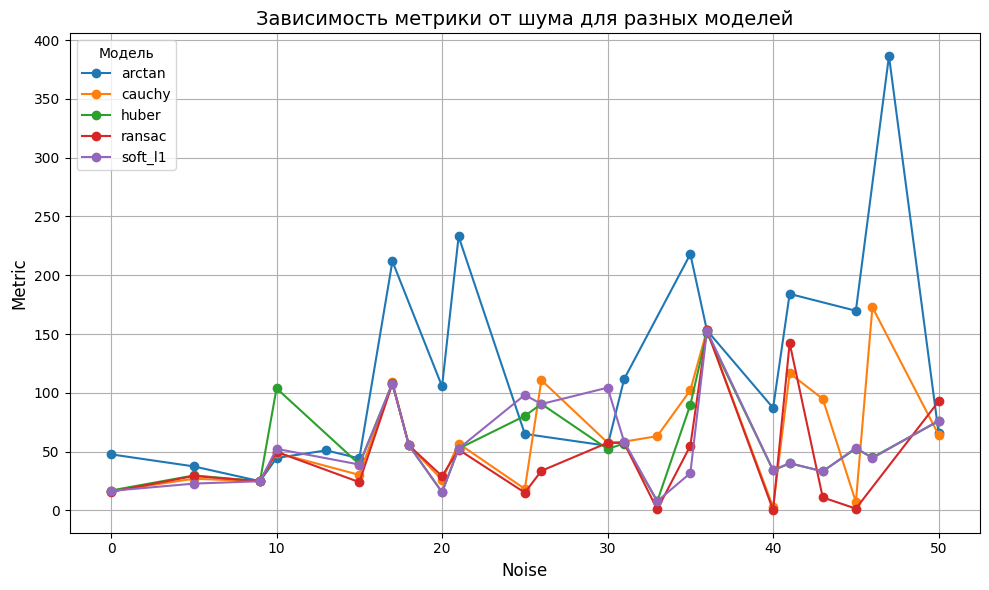

In [25]:
df = pd.read_csv('results.csv')

# Группировка по модели и шуму, расчёт средней метрики и стандартного отклонения
grouped_df = (
    df
    .groupby(['type_model', 'noise'], as_index=False)
    .agg({'metric': ['mean']})
)

# Переименование столбцов после группировки
grouped_df.columns = ['type_model', 'noise', 'metric_mean']

# Построение графика
plt.figure(figsize=(10, 6))

for model_name in grouped_df['type_model'].unique():
    subset = grouped_df[grouped_df['type_model'] == model_name]
    plt.errorbar(
        x=subset['noise'],
        y=subset['metric_mean'],
        label=model_name,
        marker='o',
        capsize=3
    )

plt.xlabel('Noise', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.title('Зависимость метрики от шума для разных моделей', fontsize=14)
plt.legend(title='Модель')
plt.grid(True)
plt.tight_layout()
plt.show()



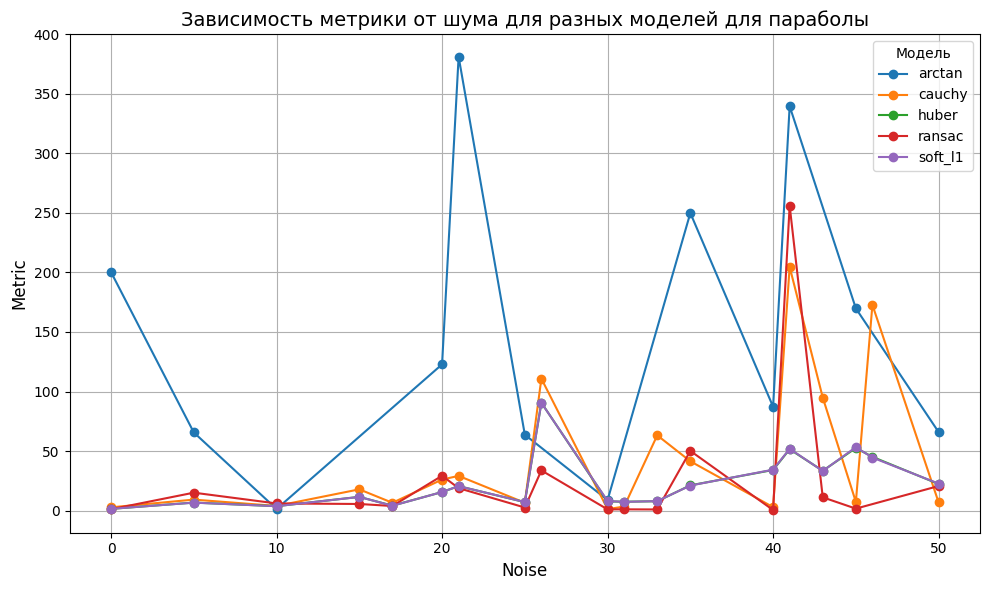

In [29]:
df = pd.read_csv('results.csv')

df = df[df['type'] == 'p']
# Группировка по модели и шуму, расчёт средней метрики и стандартного отклонения
grouped_df = (
    df
    .groupby(['type_model', 'noise'], as_index=False)
    .agg({'metric': ['mean']})
)

# Переименование столбцов после группировки
grouped_df.columns = ['type_model', 'noise', 'metric_mean']

# Построение графика
plt.figure(figsize=(10, 6))

for model_name in grouped_df['type_model'].unique():
    subset = grouped_df[grouped_df['type_model'] == model_name]
    plt.errorbar(
        x=subset['noise'],
        y=subset['metric_mean'],
        label=model_name,
        marker='o',
        capsize=3
    )

plt.xlabel('Noise', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.title('Зависимость метрики от шума для разных моделей для параболы', fontsize=14)
plt.legend(title='Модель')
plt.grid(True)
plt.tight_layout()
plt.show()


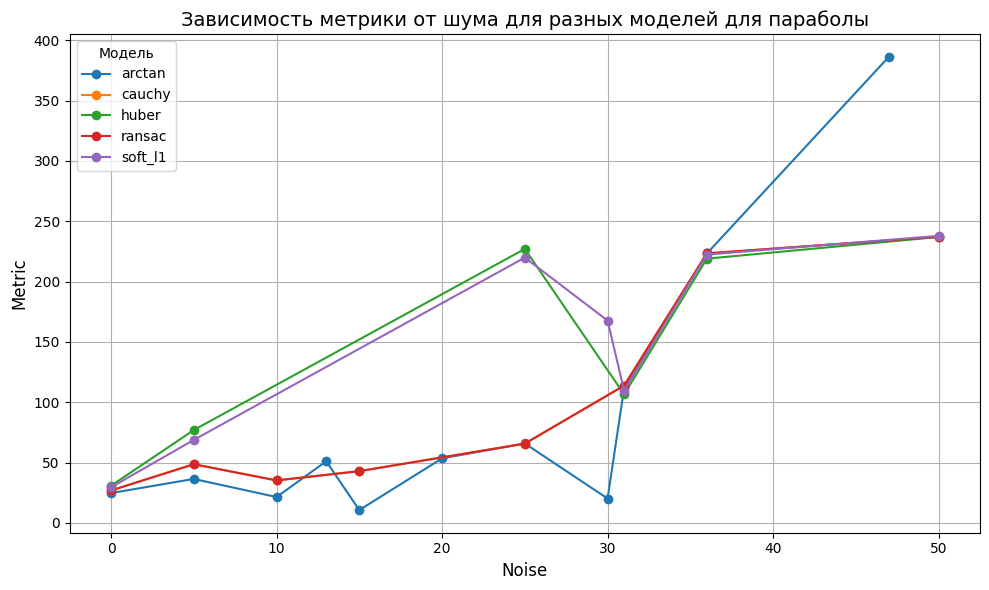

In [ ]:
df = pd.read_csv('results.csv')

df = df[df['type'] == 'e']
# Группировка по модели и шуму, расчёт средней метрики и стандартного отклонения
grouped_df = (
    df
    .groupby(['type_model', 'noise'], as_index=False)
    .agg({'metric': ['mean']})
)

# Переименование столбцов после группировки
grouped_df.columns = ['type_model', 'noise', 'metric_mean']

# Построение графика
plt.figure(figsize=(10, 6))

for model_name in grouped_df['type_model'].unique():
    subset = grouped_df[grouped_df['type_model'] == model_name]
    plt.errorbar(
        x=subset['noise'],
        y=subset['metric_mean'],
        label=model_name,
        marker='o',
        capsize=3
    )

plt.xlabel('Noise', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.title('Зависимость метрики от шума для разных моделей для эллипса', fontsize=14)
plt.legend(title='Модель')
plt.grid(True)
plt.tight_layout()
plt.show()

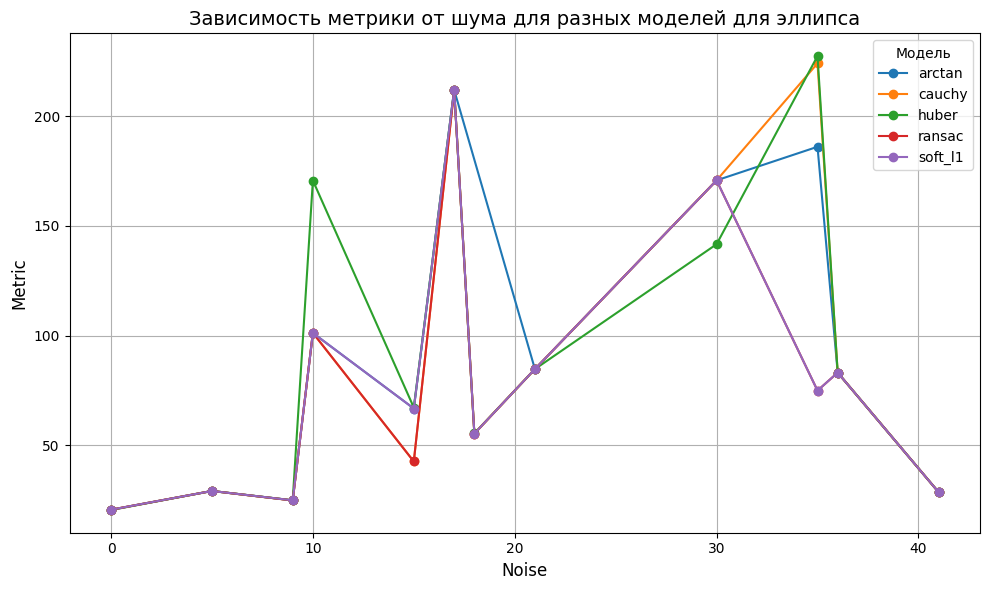

In [31]:
df = pd.read_csv('results.csv')

df = df[df['type'] == 'h']
# Группировка по модели и шуму, расчёт средней метрики и стандартного отклонения
grouped_df = (
    df
    .groupby(['type_model', 'noise'], as_index=False)
    .agg({'metric': ['mean']})
)

# Переименование столбцов после группировки
grouped_df.columns = ['type_model', 'noise', 'metric_mean']

# Построение графика
plt.figure(figsize=(10, 6))

for model_name in grouped_df['type_model'].unique():
    subset = grouped_df[grouped_df['type_model'] == model_name]
    plt.errorbar(
        x=subset['noise'],
        y=subset['metric_mean'],
        label=model_name,
        marker='o',
        capsize=3
    )

plt.xlabel('Noise', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.title('Зависимость метрики от шума для разных моделей для эллипса', fontsize=14)
plt.legend(title='Модель')
plt.grid(True)
plt.tight_layout()
plt.show()